# 3. Entscheidungsbäume (Decision Trees)

---
## 3.1 Motivation

* Logistische und lineare Regressionsmodelle lernen beide globale lineare Beziehungen
* ABER: Wenn Klassen nicht linear trennbar sind, versagt die lineare Grenze
* Abhilfe liefern Modelle, die den Raum lokal unterteilen können
* Die beste Entscheidungsregel ist die mit dem höchsten **Informationsgewinn**.
* Entscheidungsbäume neigen leicht zu **Overfitting**.
* Overfitting kann durch die Verwendung von **Pruning-Techniken** (Entfernung von Verbindungen, die keine signifikante Verbesserung der Klassifikationsleistung bringen) oder **Regularisierungstechniken** (begrenzen die Größe des Baumes) vermieden werden.

> **Merke**: Entscheidungsbäume sind ein wichtiger Ansatz im maschinellen Lernen, insbesondere im Bereich der Klassifikation und der Regression. Sie sind einfach zu verstehen, leicht zu interpretieren und bieten eine gute Leistung bei einer Vielzahl von Anwendungen.

## 3.2 Aufbau und Stoppkriterien

Die drei wichtigsten Stoppkriterien:
1. **Minimale Blattgröße (Minimum Leaf Size)**
Ein Knoten wird nur dann weiter aufgeteilt, wenn die beiden neu entstehenden Teilmengen (die Blätter) jeweils mindestens eine bestimmte Anzahl an Datenpunkten enthalten (z. B. mindestens 5 oder 10 Beobachtungen).

2. **Maximale Tiefe (Maximum Depth)**
Die Tiefe eines Baumes gibt an, wie viele Abzweigungen (Splits) der längste Weg von der Wurzel bis zu einem Blatt haben darf. Ist die maximale Tiefe beispielsweise auf 4 gesetzt, stoppt das Wachstum des Baumes exakt nach der vierten Aufteilungsebene – egal, wie die Daten dort aussehen.

3. **Keine weitere Impurity-Reduktion (Minimum Impurity Decrease)**
"Impurity" (Unreinheit) ist ein mathematisches Maß dafür, wie chaotisch oder gemischt die Daten in einem Knoten sind. Wenn in einem Knoten 50 % rote und 50 % blaue Punkte liegen, ist die Impurity maximal. Sind nur rote Punkte darin, ist die Impurity null (der Knoten ist "rein").

**Aufbau Entscheidungsbaum:**
![alt text](results/Decision_Tree_Concept.png)

**Beispiel Entscheidungsbaum:**
![alt text](results/Decision_Tree_Example.png)

### Literatur

* Benny Botsch 2023 *Maschinelles Lernen - Grundlagen und Anwendungen* Springer, Kap. 6.2 *Entscheidungsbäume*, Link: [Maschinelles Lernen - Grundlagen und Anwendungen](https://link.springer.com/book/10.1007/978-3-662-67277-8)


## 3.3 Beispiel anhand Titanic-Datensatz

**Besondere Werkzeuge:**
* `scikit-learn` für die DecisionTreeClassifier



In [88]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, roc_curve, classification_report

In [89]:
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)
 |  
 |  A decision tree classifier.
 |  
 |  Read more in the :ref:`User Guide <tree>`.
 |  
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy", "log_loss"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "log_loss" and "entropy" both for the
 |      Shannon information gain, see :ref:`tree_mathematical_formulation`.
 |  
 |  splitter : {"best", "random"}, default="best"
 |      The strategy used to choose the split at each node. Supported
 |      strat

In [90]:
data = sns.load_dataset("titanic")

In [91]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [92]:
# einfache Features wählen
X = data[["pclass", "age", "sex"]]
X = pd.get_dummies(X, drop_first=True)
y = data["survived"]

In [93]:
X.head()

,pclass,age,sex_male
0,3,22.0,True
1,1,38.0,False
2,3,26.0,False
3,1,35.0,False
4,3,35.0,True


In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42)

# stratify (dt. schichten)

In [95]:
X_train.shape

(623, 3)

In [96]:
X_test.shape

(268, 3)

### Wiederholung

Drei gebräuchliche Impurity-Maße:

1. **Gini-Impurity:**

> $$ I_{Gini}(t) = \sum_{c=1}^{K} p_{c}^{(t)} (1- p_{c}^{(t)}) = 1 - \sum_{c=1}^{K} (p_{c}^{(t)})^2  $$

mit Anzahl der Klassen $K$ und dem Anteil (die Wahrscheinlichkeit) $p_c$ einer Klasse $c$ in dem jeweiligen Knoten $t$. Gini ist der Standardwert (default) in vielen Machine Learning Bibliotheken wie z.B. scikit-learn.

**Beispiel für 2 Klassen:**
$ I_{Gini}(t) $ ist maximal bei Unreinheit (50% / 50%) - Verteilung: 
$$1 - (0.5^2 + 0.5^2) = 0.5$$

---
2. **Entropie (Information Gain):**

> $$ I_{Ent}(t) = - \sum_{c=1}^{K} p_{c}^{(t)} \log_2 p_{c}^{(t)} $$

Entropie stammt ursprünglich aus der Informationstheorie und misst den Grad der "Unordnung" in einem System.

**Beispiel für 2 Klassen:**
$ I_{Ent}(t) $ ist maximal bei Unreinheit (50% / 50%) - Verteilung: 
$$ - (0.5 \cdot (-1) + 0.5 \cdot (-1)) = 1 $$

---
3. **Fehlklassifikationsrate:**

> $$ I_{Err}(t) = 1 - \max_{c} p_{c}^{(t)} $$

Gibt einfach den Anteil der Datenpunkte im Knoten an, die nicht zur Mehrheitsklasse gehören. Wird eher zum Pruning als zum Trainieren / Wachsen verwendet.

**Beispiel für 2 Klassen:**
$ I_{Err}(t) $ ist maximal bei Unreinheit (50% / 50%) - Verteilung: 
$$ 1 - 0.5 = 0.5 $$

---
Maß für Informationsgewinn: **Delta-Gini**

> $$ \Delta I(t) = I_{parent} - \frac{n_L}{n} I_L - \frac{n_R}{n} I_R $$

Das Delta Gini ($\Delta I$) nennt man auch Informationsgewinn (Information Gain). Es berechnet das, was Ziel jedes Splits ist: Wie viel "Ordnung" haben wir durch die Aufteilung gewonnen? Mit Gini-Impurity des Elterknotens $I_{Parent}$, der Gesamtanzahl der Datenpunkte im Elternknoten $n$ sowie der Datenpunkte links $n_L$ und rechts $n_R$ nach der Abzweigung. $I_L$ und $I_R$ beschreiben die Gini-Impurity nach den beiden Kindknoten.

---
**Modellkomplxität bei Enscheidungsbäumen**

* **Modellkomplexität** bei Entscheidungsbäumen beschreibt, wie tief und detailliert verzweigt der Baum wachsen darf, um die Trainingsdaten abzubilden.
* **Bias (Verzerrung)** ist der Fehler durch zu simple Modellannahmen und ist bei sehr flachen Bäumen hoch, da diese dazu neigen, wichtige Muster in den Daten zu übersehen (sog. **Underfitting**)
* **Varianz** ist der Fehler durch eine zu hohe Empfindlichkeit gegenüber den Trainingsdaten und ist oft bei sehr tiefen Bäumen hoch, da diese Ausreißer und Rauschen "auswendig" lernen (sog. **Overfitting**)
* **Bias-Varianz-Tradeoff** beschreibt den Zielkonflikt, dass jede Erhöhung der Modellkomplexität den Bias senkt, aber gleichzeitig unweigerlich die Varianz erhöht (und umgekehrt)

In [97]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [98]:
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

In [99]:
model.get_n_leaves()

np.int64(111)

In [100]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [101]:
y_pred_train[1:10]

array([0, 1, 0, 0, 1, 0, 0, 0, 0])

In [102]:
y_pred_test[1:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 1])

In [103]:
y_prob_test = model.predict_proba(X_test)

In [104]:
y_prob_test[1:10]

array([[0.88888889, 0.11111111],
       [0.91176471, 0.08823529],
       [0.5       , 0.5       ],
       [1.        , 0.        ],
       [1.        , 0.        ],
       [0.8       , 0.2       ],
       [0.        , 1.        ],
       [0.83333333, 0.16666667],
       [0.        , 1.        ]])

In [105]:
print("Accuracy Train:", accuracy_score(y_train, y_pred_train))
print("Accuracy Test :", accuracy_score(y_test, y_pred_test))

Accuracy Train: 0.8876404494382022
Accuracy Test : 0.8059701492537313


In [106]:
acc = accuracy_score(y_test, y_pred_test)
prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred_test, average="binary")
auc = roc_auc_score(y_test, y_prob_test[:,1])

print(f"Accuracy={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}  ROC-AUC={auc:.3f}")

Accuracy=0.806  Precision=0.800  Recall=0.660  F1=0.723  ROC-AUC=0.769


In [107]:
print("Classification Report – Decision Tree")
print(classification_report(y_test, y_pred_test, digits=3))

Classification Report – Decision Tree
              precision    recall  f1-score   support

           0      0.809     0.897     0.851       165
           1      0.800     0.660     0.723       103

    accuracy                          0.806       268
   macro avg      0.804     0.779     0.787       268
weighted avg      0.805     0.806     0.802       268



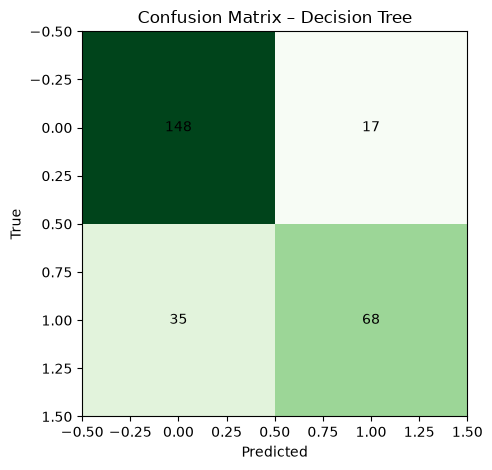

In [108]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='Greens')
plt.title("Confusion Matrix – Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("True")
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.show()

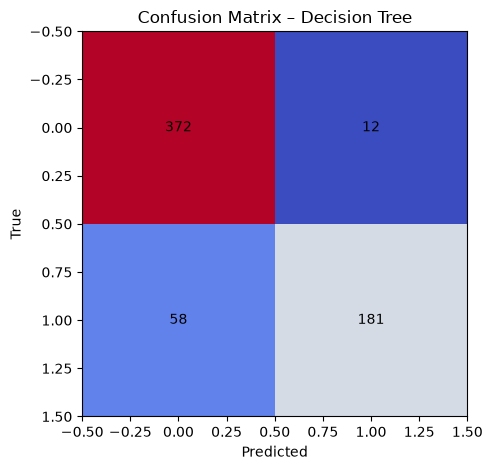

In [109]:
cm = confusion_matrix(y_train, y_pred_train)

plt.figure()
plt.imshow(cm, interpolation='nearest', cmap='coolwarm')
plt.title("Confusion Matrix – Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("True")
for (i, j), v in np.ndenumerate(cm):
    plt.text(j, i, str(v), ha='center', va='center')
plt.tight_layout()
plt.show()

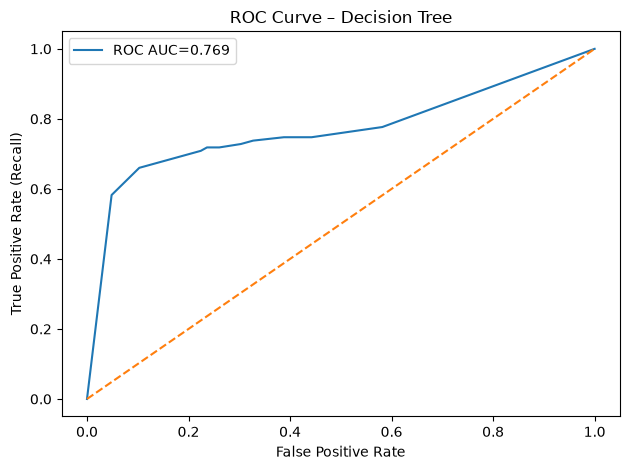

In [56]:
fpr, tpr, thr = roc_curve(y_test, y_prob_test[:,1])
plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC={auc:.3f}")
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – Decision Tree")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation der ROC-Kurve

Die **ROC-Kurve (Receiver Operating Characteristic)** zeigt, wie gut das Modell zwischen den beiden Klassen unterscheiden kann – unabhängig von der gewählten Entscheidungsschwelle.

- **x-Achse:** *False Positive Rate (FPR)*  
  Anteil negativer Fälle, die fälschlich als positiv klassifiziert wurden.  
  \( $\text{FPR} = \frac{\text{FP}}{\text{FP} + \text{TN}} $\)

- **y-Achse:** *True Positive Rate (Recall)*  
  Anteil tatsächlicher Positiver, die richtig erkannt wurden.  
  \( $\text{TPR} = \frac{\text{TP}}{\text{TP} + \text{FN}} $\)

- **Orange gestrichelte Linie:** Zufallsentscheidung (AUC = 0.5)

- **Blaue Linie:** Das Modell – je weiter sie oben links liegt, desto besser.

Der **AUC-Wert (Area Under Curve)** fasst die Trennschärfe in einer Zahl zusammen:
- **1.0** → perfektes Modell  
- **0.5** → Zufall  
- **0.768** → gutes, aber nicht perfektes Modell

Ein Decision Tree erreicht typischerweise AUC-Werte zwischen 0.7 und 0.8.  
Er unterscheidet also brauchbar zwischen „positiv“ und „negativ“, kann aber durch *Pruning* oder *Ensembles* (z. B. Random Forest, Boosting) oft noch verbessert werden.


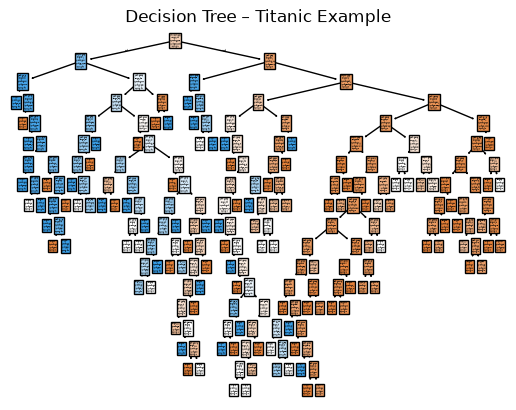

In [111]:
plot_tree(model, feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.title("Decision Tree – Titanic Example")
plt.savefig("./results/decision_tree_titanic01.png", dpi=3000) 

In [58]:
model.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

### Experimentieren mit Hyperparametern des Decision Trees

Unten sind typische Parameter eines `DecisionTreeClassifier` aufgeführt, die sich gut eignen, um den Einfluss auf Overfitting, Generalisierung und Modellstruktur zu erkunden.  

---

#### 1. **Baumkomplexität steuern**
| Parameter | Beschreibung | Beispielwerte / Experimente |
|------------|---------------|------------------------------|
| `max_depth` | Maximale Tiefe des Baums. Begrenzt, wie oft gesplittet werden darf. | `None` (unbegrenzt), `3`, `5`, `10`, `20` |
| `min_samples_split` | Mindestanzahl an Samples, die nötig sind, um einen Knoten zu teilen. | `2`, `5`, `10`, `20` |
| `min_samples_leaf` | Mindestanzahl an Samples in einem Blatt. | `1`, `3`, `5`, `10` |
| `max_leaf_nodes` | Maximale Anzahl Blätter. Alternativer Weg, die Komplexität zu begrenzen. | `None`, `10`, `20`, `50` |

---

#### 2. **Split-Kriterien und Strategien**
| Parameter | Beschreibung | Beispielwerte / Experimente |
|------------|---------------|------------------------------|
| `criterion` | Maß für die Homogenität der Knoten. | `'gini'`, `'entropy'`, `'log_loss'` |
| `splitter` | Strategie zur Auswahl der Splitpunkte. | `'best'` (Standard), `'random'` (führt zu variableren, oft flacheren Bäumen) |

---

#### 3. **Feature-Auswahl und Gewichtung**
| Parameter | Beschreibung | Beispielwerte / Experimente |
|------------|---------------|------------------------------|
| `max_features` | Anzahl der Features, die bei einem Split berücksichtigt werden. | `None`, `'sqrt'`, `'log2'`, feste Zahl (`3`, `5` …) |
| `class_weight` | Gewichtung der Klassen (nützlich bei unbalancierten Datensätzen). | `None`, `'balanced'` |

---

#### 4. **Regularisierung / Pruning**
| Parameter | Beschreibung | Beispielwerte / Experimente |
|------------|---------------|------------------------------|
| `ccp_alpha` | Komplexitätsparameter für Cost-Complexity-Pruning. Größere Werte → stärkeres Pruning. | `0.0`, `0.001`, `0.01`, `0.05` |
| `min_impurity_decrease` | Mindestverbesserung der Gini-Impurity, um einen Split durchzuführen. | `0.0`, `0.001`, `0.01` |

---

#### 5. **Zufälligkeit und Reproduzierbarkeit**
| Parameter | Beschreibung | Beispielwerte / Experimente |
|------------|---------------|------------------------------|
| `random_state` | Zufallsseed für Reproduzierbarkeit. | `None`, `42`, `1`, `123` |

---

**Aufgabe:**  
Wählt 2–3 Parameter aus und verändert sie systematisch.  
Beobachtet anschließend:
- Wie ändern sich **Train- und Test-Accuracy**?  
- Wie verändert sich die **Baumstruktur** (Tiefe, Anzahl Blätter)?  
- Wann tritt **Overfitting** auf?

So bekommt ihr ein Gefühl dafür, wie man die Komplexität und Generalisierungsfähigkeit eines Entscheidungsbaums steuern kann.


In [59]:
for crit in ["gini", "entropy"]:
    model2 = DecisionTreeClassifier(max_depth=3, criterion=crit, random_state=42)
    model2.fit(X_train, y_train)
    print(f"{crit} - Accuracy Test:", model2.score(X_test, y_test))

gini - Accuracy Test: 0.7723880597014925
entropy - Accuracy Test: 0.7723880597014925


In [60]:
model = DecisionTreeClassifier(min_impurity_decrease = 0.1, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.1
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspec

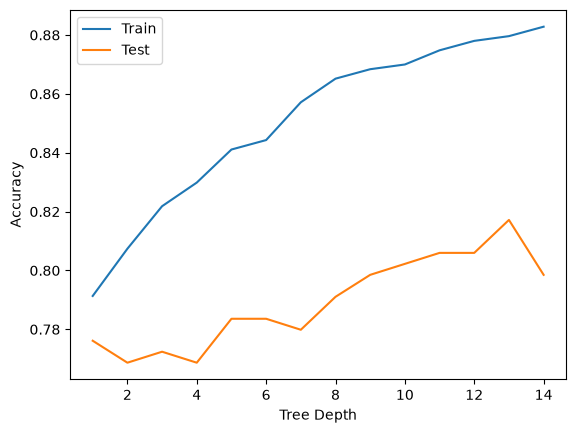

In [61]:
depths = range(1, 15)
train_acc, test_acc = [], []

for d in depths:
    model1 = DecisionTreeClassifier(max_depth=d, random_state=42)
    model1.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, model1.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model1.predict(X_test)))

plt.plot(depths, train_acc, label="Train")
plt.plot(depths, test_acc, label="Test")
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Einfluss der Baumtiefe auf Trainings- und Testgenauigkeit

Dieser Plot zeigt, wie sich die **Tiefe des Entscheidungsbaums (`max_depth`)** auf die **Accuracy** auswirkt – getrennt für Trainings- und Testdaten.

#### Interpretation:
- **Train (blaue Linie):**  
  Mit zunehmender Tiefe steigt die Trainingsgenauigkeit stetig an.  
  Der Baum kann die Trainingsdaten immer besser anpassen und irgendwann **nahezu perfekt** klassifizieren.  
  → Das ist typisch für **Overfitting**.

- **Test (orange Linie):**  
  Auf den Testdaten verbessert sich die Genauigkeit zunächst, erreicht aber ein Plateau  
  und fällt danach leicht ab.  
  → Der Baum lernt zunehmend **Rauschen** in den Trainingsdaten statt allgemeine Muster.

#### Fazit:
- **Kleine Tiefe → Underfitting:** Der Baum ist zu einfach, erkennt Muster nicht.  
- **Mittlere Tiefe → Optimaler Bereich:** Gute Balance zwischen Bias und Varianz.  
- **Große Tiefe → Overfitting:** Der Baum passt sich zu stark an Trainingsdaten an und verallgemeinert schlechter.

Der ideale Wert für `max_depth` liegt dort, wo die Testgenauigkeit am höchsten ist.


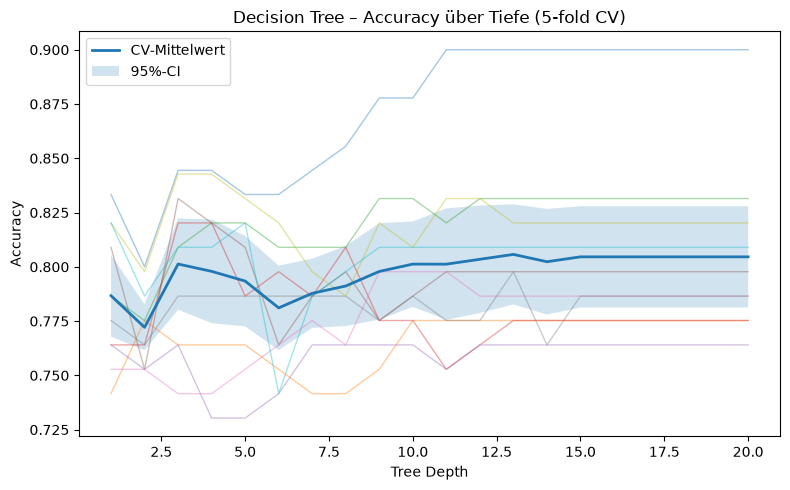

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier

X_all, y_all = X, y  # falls deine Variablen anders heißen
depths = range(1, 21)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Scores: shape = (n_splits, n_depths)
all_scores = np.zeros((cv.get_n_splits(), len(depths)))

for j, d in enumerate(depths):
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(model, X_all, y_all, cv=cv, scoring="accuracy")
    all_scores[:, j] = scores

mean_scores = all_scores.mean(axis=0)
std_scores  = all_scores.std(axis=0)
sem_scores  = std_scores / np.sqrt(all_scores.shape[0])  # Standardfehler
ci95_low    = mean_scores - 1.96 * sem_scores
ci95_high   = mean_scores + 1.96 * sem_scores

plt.figure(figsize=(8,5))

# alle Fold-Linien (transparent)
for k in range(all_scores.shape[0]):
    plt.plot(depths, all_scores[k, :], linewidth=1, alpha=0.4)

# Mittelwert + 95%-CI-Band
plt.plot(depths, mean_scores, linewidth=2, label="CV-Mittelwert")
plt.fill_between(depths, ci95_low, ci95_high, alpha=0.2, label="95%-CI")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree – Accuracy über Tiefe (5-fold CV)")
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation der CV-Accuracy über die Baumtiefe

Der Plot zeigt die mittlere Klassifikationsgenauigkeit (Accuracy) eines Decision Trees in Abhängigkeit von der **Baumtiefe**.  
Die dünnen Linien stellen die Ergebnisse der einzelnen Cross-Validation-Folds dar,  
die blaue Linie den Mittelwert und das blaue Band das 95%-Konfidenzintervall.

**Beobachtungen:**
- Die Linien der einzelnen Folds schwanken deutlich, vor allem bei kleinen Baumtiefen.
- Der Mittelwert bleibt relativ stabil, ohne einen klar ausgeprägten optimalen Punkt zu zeigen.
- Die Unsicherheiten (Konfidenzband) sind relativ groß, was auf eine hohe Varianz der CV-Ergebnisse hindeutet.

**Mögliche Ursachen:**
1. **Kleine Feature-Anzahl (nur 3 Merkmale):**  
   Der Baum hat nur begrenzte Trennmöglichkeiten und kann keine komplexeren Muster lernen.

2. **Geringe Stichprobengröße:**  
   Wenn das Dataset klein ist, unterscheiden sich die Trainings- und Testaufteilungen in den Folds stark, was zu schwankenden Ergebnissen führt.

3. **Hohe Überlappung der Klassen im Feature-Raum:**  
   Wenn sich die Klassen anhand der vorhandenen Features schlecht trennen lassen, reagiert der Baum empfindlich auf zufällige Unterschiede in den Daten.

4. **Fehlende Regularisierung oder unbalancierte Klassen:**  
   Ein unbalancierter Datensatz oder ein nicht optimal gewählter Score (z. B. Accuracy statt F1) kann ebenfalls die Stabilität beeinflussen.

**Fazit:**
Die Cross-Validation zeigt, dass die Modellgüte über die Tiefe hinweg nur schwach variiert und insgesamt unsicher ist.  
Das deutet darauf hin, dass entweder mehr oder aussagekräftigere Features benötigt werden oder ein anderes Modell (z. B. Random Forest oder Boosting) stabilere Ergebnisse liefern könnte.


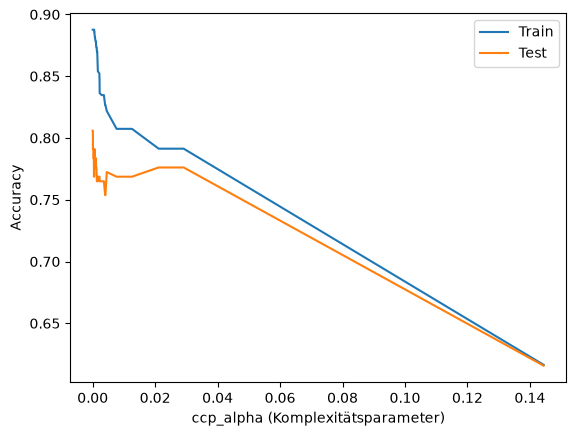

In [63]:
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

train_scores = []
test_scores = []

for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.plot(ccp_alphas, train_scores, label='Train')
plt.plot(ccp_alphas, test_scores, label='Test')
plt.xlabel("ccp_alpha (Komplexitätsparameter)")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Interpretation der Cost-Complexity-Pruning-Kurve

Die Grafik zeigt, wie sich die Genauigkeit von Trainings- und Testdaten mit zunehmendem **Komplexitätsparameter** `ccp_alpha` verändert.

**Hintergrund:**
Beim Cost-Complexity-Pruning (auch „post-pruning“) wird der vollständig gewachsene Baum nachträglich vereinfacht.  
Der Parameter `ccp_alpha` steuert, wie stark Knoten mit geringem Informationsgewinn entfernt werden.

- Kleine Werte von `ccp_alpha` → kaum oder kein Pruning → sehr komplexer Baum  
- Große Werte von `ccp_alpha` → stärkeres Pruning → einfacherer, flacher Baum

**Interpretation der Kurven:**
- **Train (blaue Linie):**  
  Mit steigendem `ccp_alpha` nimmt die Trainingsgenauigkeit stetig ab.  
  Der Baum verliert Komplexität und kann die Trainingsdaten nicht mehr perfekt abbilden.

- **Test (orange Linie):**  
  Zunächst bleibt die Genauigkeit stabil oder steigt leicht an, weil das Modell generalisiert.  
  Ab einem bestimmten Punkt fällt die Genauigkeit wieder ab, da der Baum zu stark vereinfacht wurde und relevante Muster verliert.

**Fazit:**
Es gibt einen Bereich mittlerer `ccp_alpha`-Werte, in dem die Testgenauigkeit am höchsten ist.  
Dort liegt der optimale Kompromiss zwischen Modellkomplexität und Generalisierungsfähigkeit.

---

## Beispiel: Manuelle Split-Definition mittels Gini und Delta-Gini

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [65]:
data = pd.DataFrame({
    "sweetness": [1,2,2,3,8,9,8,7],
    "crunchiness": [9,8,7,9,2,3,1,2],
    "label": ["Chips","Chips","Chips","Chips","Gummi","Gummi","Gummi","Gummi"]
})

<Axes: xlabel='sweetness', ylabel='crunchiness'>

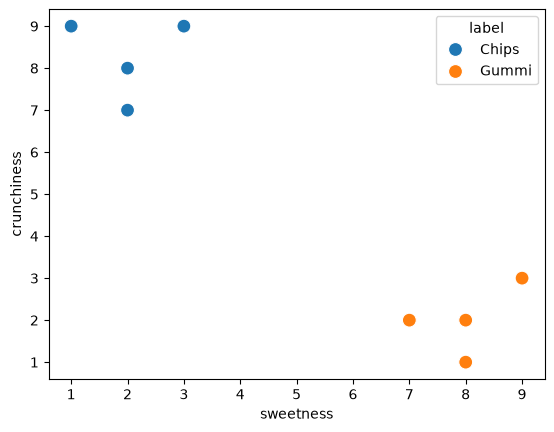

In [66]:
sns.scatterplot(data=data, x="sweetness", y="crunchiness", hue="label", s=100)

In [67]:
# --- Funktion zur Berechnung der Gini-Impurity ---
def gini_impurity(y):
    p = y.value_counts(normalize=True)
    return 1 - (p**2).sum()

In [68]:
# --- Gini des Parent-Knotens ---
parent_gini = gini_impurity(data["label"])

print(f"Gini des Parent-Knotens: {parent_gini:.3f}\n")


Gini des Parent-Knotens: 0.500



In [69]:
# --- Splitanalyse ---
thresholds = range(1, 10)
gini_values = []
delta_gini_values = []

print("t | Gini-Left | Gini-Right | Weighted Gini | ΔGini (Info-Gain)")
print("-"*65)

for t in thresholds:
    left = data[data["sweetness"] < t]["label"]
    right = data[data["sweetness"] >= t]["label"]
    
    gini_left = gini_impurity(left)
    gini_right = gini_impurity(right)
    weighted_gini = (
        len(left)/len(data)*gini_left
        + len(right)/len(data)*gini_right
    )
    delta_gini = parent_gini - weighted_gini
    
    gini_values.append(weighted_gini)
    delta_gini_values.append(delta_gini)
    
    print(f"{t:>2} | {gini_left:>10.3f} | {gini_right:>11.3f} | {weighted_gini:>14.3f} | {delta_gini:>16.3f}")

t | Gini-Left | Gini-Right | Weighted Gini | ΔGini (Info-Gain)
-----------------------------------------------------------------
 1 |      1.000 |       0.500 |          0.500 |            0.000
 2 |      0.000 |       0.490 |          0.429 |            0.071
 3 |      0.000 |       0.320 |          0.200 |            0.300
 4 |      0.000 |       0.000 |          0.000 |            0.500
 5 |      0.000 |       0.000 |          0.000 |            0.500
 6 |      0.000 |       0.000 |          0.000 |            0.500
 7 |      0.000 |       0.000 |          0.000 |            0.500
 8 |      0.320 |       0.000 |          0.200 |            0.300
 9 |      0.490 |       0.000 |          0.429 |            0.071


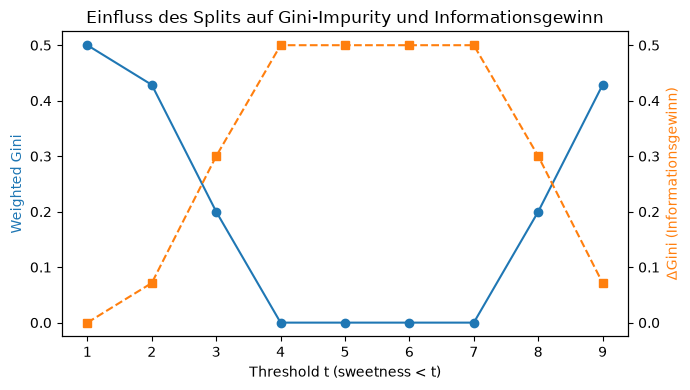

In [70]:
# --- Visualisierung: Gini & ΔGini ---
fig, ax1 = plt.subplots(figsize=(7,4))
ax1.plot(thresholds, gini_values, marker='o', label="Weighted Gini", color="tab:blue")
ax1.set_xlabel("Threshold t (sweetness < t)")
ax1.set_ylabel("Weighted Gini", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(thresholds, delta_gini_values, marker='s', linestyle='--', label="ΔGini (Info-Gain)", color="tab:orange")
ax2.set_ylabel("ΔGini (Informationsgewinn)", color="tab:orange")

plt.title("Einfluss des Splits auf Gini-Impurity und Informationsgewinn")
fig.tight_layout()
plt.show()

In [71]:
# --- Optimalen Split ausgeben ---
best_t = thresholds[pd.Series(gini_values).idxmin()]
print(f"\n Optimaler Split bei t = {best_t} "
      f"(min Gini = {min(gini_values):.3f}, max ΔGini = {max(delta_gini_values):.3f})")


 Optimaler Split bei t = 4 (min Gini = 0.000, max ΔGini = 0.500)


In [72]:
def gini_impurity(y: pd.Series) -> float:
    y = y.dropna()
    if len(y) == 0:
        return 0.0
    p = y.value_counts(normalize=True)
    return 1 - (p**2).sum()

In [73]:
def analyze_numeric_feature(df: pd.DataFrame, feature: str, target: str, *, max_unique: int = 200):
    """
    Prüft alle Midpoint-Schwellen des numerischen Features und gibt eine Tabelle
    mit Gini_left, Gini_right, weighted_gini und ΔGini zurück.
    Zusätzlich wird der beste Split (min weighted_gini / max ΔGini) angezeigt.

    Returns
    -------
    results_df : pd.DataFrame (sortiert nach weighted_gini aufsteigend)
    best_row   : pd.Series (beste Zeile)
    parent_gini: float
    """
    if feature not in df.columns or target not in df.columns:
        raise KeyError("Feature oder Target nicht in DataFrame.")

    x = df[feature]
    y = df[target]
    if not pd.api.types.is_numeric_dtype(x):
        raise TypeError(f"Feature '{feature}' ist nicht numerisch.")

    # Parent-Gini
    parent_gini = gini_impurity(y)

    # Midpoints zwischen sortierten Unique-Werten
    vals = np.sort(x.dropna().unique())
    if len(vals) <= 1:
        raise ValueError(f"Feature '{feature}' hat nicht genug unterschiedliche Werte.")
    if len(vals) > max_unique:
        idx = np.linspace(0, len(vals)-1, max_unique).round().astype(int)
        vals = vals[idx]
    thresholds = (vals[:-1] + vals[1:]) / 2.0

    rows = []
    n = len(df)
    for t in thresholds:
        left_mask = x < t
        right_mask = ~left_mask
        yL, yR = y[left_mask], y[right_mask]
        if len(yL) == 0 or len(yR) == 0:
            continue
        gL, gR = gini_impurity(yL), gini_impurity(yR)
        weighted_g = (len(yL)/n)*gL + (len(yR)/n)*gR
        dG = parent_gini - weighted_g
        rows.append({
            "feature": feature,
            "threshold": float(t),
            "n_left": int(len(yL)),
            "n_right": int(len(yR)),
            "gini_left": gL,
            "gini_right": gR,
            "weighted_gini": weighted_g,
            "delta_gini": dG
        })

    if not rows:
        raise ValueError("Keine gültigen Splits gefunden (evtl. NaNs/konstante Werte).")

    results_df = pd.DataFrame(rows).sort_values(["weighted_gini", "delta_gini"], ascending=[True, False]).reset_index(drop=True)

    # Schöne Konsolen-Ausgabe
    print(f"\nFeature: {feature} | Gini(Parent) = {parent_gini:.3f}")
    print("t (threshold) | nL | nR | G_left | G_right | Weighted_G | ΔGini")
    print("-"*70)
    for _, r in results_df.head(20).iterrows():  # nicht endlos lang werden
        print(f"{r['threshold']:>12.4f} | {r['n_left']:>2} | {r['n_right']:>2} | "
              f"{r['gini_left']:>6.3f} | {r['gini_right']:>7.3f} | "
              f"{r['weighted_gini']:>10.3f} | {r['delta_gini']:>6.3f}")

    best_row = results_df.iloc[0]
    print(f"\n➡Bester Split für '{feature}': {feature} < {best_row['threshold']:.4f}  "
          f"(min weighted_gini = {best_row['weighted_gini']:.3f}, max ΔGini = {best_row['delta_gini']:.3f})")

    return results_df, best_row, parent_gini


In [74]:
# sweetness analysieren
tab_sweet, best_sweet, parent_g = analyze_numeric_feature(data, "sweetness", "label")


Feature: sweetness | Gini(Parent) = 0.500
t (threshold) | nL | nR | G_left | G_right | Weighted_G | ΔGini
----------------------------------------------------------------------
      5.0000 |  4 |  4 |  0.000 |   0.000 |      0.000 |  0.500
      2.5000 |  3 |  5 |  0.000 |   0.320 |      0.200 |  0.300
      7.5000 |  5 |  3 |  0.320 |   0.000 |      0.200 |  0.300
      1.5000 |  1 |  7 |  0.000 |   0.490 |      0.429 |  0.071
      8.5000 |  7 |  1 |  0.490 |   0.000 |      0.429 |  0.071

➡Bester Split für 'sweetness': sweetness < 5.0000  (min weighted_gini = 0.000, max ΔGini = 0.500)


In [75]:
# crunchiness analysieren
tab_crunch, best_crunch, _ = analyze_numeric_feature(data, "crunchiness", "label")


Feature: crunchiness | Gini(Parent) = 0.500
t (threshold) | nL | nR | G_left | G_right | Weighted_G | ΔGini
----------------------------------------------------------------------
      5.0000 |  4 |  4 |  0.000 |   0.000 |      0.000 |  0.500
      2.5000 |  3 |  5 |  0.000 |   0.320 |      0.200 |  0.300
      7.5000 |  5 |  3 |  0.320 |   0.000 |      0.200 |  0.300
      8.5000 |  6 |  2 |  0.444 |   0.000 |      0.333 |  0.167
      1.5000 |  1 |  7 |  0.000 |   0.490 |      0.429 |  0.071

➡Bester Split für 'crunchiness': crunchiness < 5.0000  (min weighted_gini = 0.000, max ΔGini = 0.500)


In [76]:
def plot_split(data, feature, threshold):
    plt.figure(figsize=(5,5))
    sns.scatterplot(data=data, x="sweetness", y="crunchiness", hue="label", s=100)
    if feature == "sweetness":
        plt.axvline(threshold, color="black", linestyle="--")
    else:
        plt.axhline(threshold, color="black", linestyle="--")

In [77]:
X = data[["sweetness","crunchiness"]]
y = data["label"]
clf = DecisionTreeClassifier(max_depth=2, criterion="gini", random_state=0)
clf.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

[Text(0.5, 0.75, 'crunchiness <= 5.0\ngini = 0.5\nsamples = 8\nvalue = [4, 4]\nclass = Chips'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [0, 4]\nclass = Gummi'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.0\nsamples = 4\nvalue = [4, 0]\nclass = Chips'),
 Text(0.625, 0.5, '  False')]

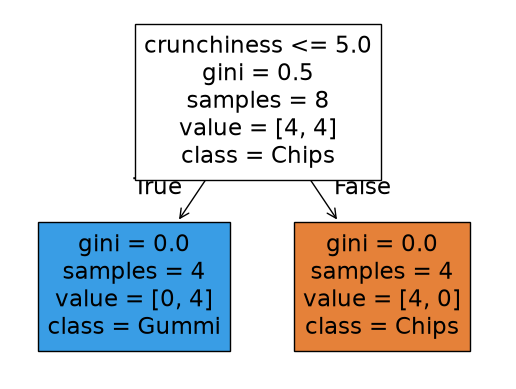

In [78]:
plot_tree(clf, feature_names=["sweetness","crunchiness"], class_names=clf.classes_, filled=True)

In [79]:
np.random.seed(0)
n = 100
data = pd.DataFrame({
    "sweetness": np.random.uniform(0,10,n),
    "crunchiness": np.random.uniform(0,10,n),
})
data["label"] = np.where(
    data["sweetness"] + np.random.normal(0,1,n) > data["crunchiness"], "Gummi", "Chips"
)

In [80]:
def gini_impurity(y: pd.Series) -> float:
    y = y.dropna()
    if len(y) == 0:
        return 0.0
    p = y.value_counts(normalize=True)
    return 1 - (p**2).sum()

In [81]:
def numeric_thresholds(s: pd.Series, max_unique: int = 100):
    """Midpoints zwischen sortierten Unique-Werten als Kandidaten.
       max_unique limitiert sehr feingranulare Features."""
    vals = np.sort(s.dropna().unique())
    if len(vals) <= 1:
        return []
    if len(vals) > max_unique:
        # gleichmäßig sampeln, damit es flott bleibt
        idx = np.linspace(0, len(vals)-1, max_unique).round().astype(int)
        vals = vals[idx]
    mids = (vals[:-1] + vals[1:]) / 2.0
    return mids

In [82]:
def evaluate_numeric_split(X_col: pd.Series, y: pd.Series, thresholds):
    parent_g = gini_impurity(y)
    rows = []
    for t in thresholds:
        left_mask = X_col < t
        right_mask = ~left_mask
        yL, yR = y[left_mask], y[right_mask]
        if len(yL) == 0 or len(yR) == 0:
            continue
        gL, gR = gini_impurity(yL), gini_impurity(yR)
        w = len(yL)/len(y)*gL + len(yR)/len(y)*gR
        d = parent_g - w
        rows.append({"threshold": float(t), "gini_left": gL, "gini_right": gR,
                     "weighted_gini": w, "delta_gini": d,
                     "n_left": len(yL), "n_right": len(yR)})
    if not rows:
        return None, None, None
    df = pd.DataFrame(rows).sort_values("weighted_gini")
    best = df.iloc[0]
    return df, "numeric", best

In [83]:
def evaluate_categorical_split(X_col: pd.Series, y: pd.Series, max_categories: int = 20):
    """One-vs-Rest für jede Kategorie (didaktisch & effizient)."""
    parent_g = gini_impurity(y)
    cats = X_col.dropna().astype("category").cat.categories.tolist()
    if len(cats) == 0:
        return None, None, None
    if len(cats) > max_categories:
        # viele Kategorien -> nimm häufigste top-k
        top = X_col.value_counts().head(max_categories).index.tolist()
        cats = [c for c in cats if c in top]
    rows = []
    for c in cats:
        left_mask = (X_col == c)  # {c} vs Rest
        right_mask = ~left_mask
        yL, yR = y[left_mask], y[right_mask]
        if len(yL) == 0 or len(yR) == 0:
            continue
        gL, gR = gini_impurity(yL), gini_impurity(yR)
        w = len(yL)/len(y)*gL + len(yR)/len(y)*gR
        d = parent_g - w
        rows.append({"category": c, "gini_left": gL, "gini_right": gR,
                     "weighted_gini": w, "delta_gini": d,
                     "n_left": len(yL), "n_right": len(yR)})
    if not rows:
        return None, None, None
    df = pd.DataFrame(rows).sort_values("weighted_gini")
    best = df.iloc[0]
    return df, "categorical", best

In [84]:
def find_best_split(X: pd.DataFrame, y: pd.Series, verbose=True):
    """Suche über alle Spalten: bester Split (numeric thresholds / categorical one-vs-rest)."""
    parent_g = gini_impurity(y)
    if verbose:
        print(f"Gini (Parent): {parent_g:.4f}\n")

    candidates = []   # sammelt nur die Bestwerte je Feature
    details = {}      # speichert komplette Tabellen pro Feature

    for col in X.columns:
        s = X[col]
        if pd.api.types.is_numeric_dtype(s):
            ths = numeric_thresholds(s)
            df, ftype, best = evaluate_numeric_split(s, y, ths)
        else:
            df, ftype, best = evaluate_categorical_split(s, y)

        if df is None:
            continue
        details[col] = (ftype, df)
        row = {
            "feature": col,
            "type": ftype,
            "weighted_gini": best["weighted_gini"],
            "delta_gini": best["delta_gini"],
            "n_left": int(best["n_left"]),
            "n_right": int(best["n_right"])
        }
        if ftype == "numeric":
            row["rule"] = f"{col} < {best['threshold']:.4f}"
        else:
            row["rule"] = f"{col} == '{best['category']}'"
        candidates.append(row)

    if not candidates:
        if verbose:
            print("Kein gültiger Split gefunden (evtl. nur 1 Klasse oder zu viele NaNs).")
        return None, None, None

    cand_df = pd.DataFrame(candidates).sort_values(["weighted_gini", "delta_gini"], ascending=[True, False])
    if verbose:
        print("Beste Kandidaten pro Feature (sortiert):")
        print(cand_df[["feature","type","rule","weighted_gini","delta_gini","n_left","n_right"]].to_string(index=False))
        print()

    # global bester Split
    best_row = cand_df.iloc[0]
    best_feature = best_row["feature"]
    best_type, df_full = details[best_feature]

    if verbose:
        print(f"➡️ Bester Split: {best_row['rule']}")
        print(f"   weighted Gini = {best_row['weighted_gini']:.4f}, ΔGini = {best_row['delta_gini']:.4f}")
    return best_row, details, cand_df

In [85]:
snacks = pd.DataFrame({
    "sweetness": [1,2,2,3,8,9,8,7],
    "crunchiness": [9,8,7,9,2,3,1,2],
    "label": ["Chips","Chips","Chips","Chips","Gummi","Gummi","Gummi","Gummi"]
})

X_snack = snacks[["sweetness","crunchiness"]]
y_snack = snacks["label"]

best, details, ranking = find_best_split(X_snack, y_snack, verbose=True)

Gini (Parent): 0.5000

Beste Kandidaten pro Feature (sortiert):
    feature    type                 rule  weighted_gini  delta_gini  n_left  n_right
  sweetness numeric   sweetness < 5.0000            0.0         0.5       4        4
crunchiness numeric crunchiness < 5.0000            0.0         0.5       4        4

➡️ Bester Split: sweetness < 5.0000
   weighted Gini = 0.0000, ΔGini = 0.5000


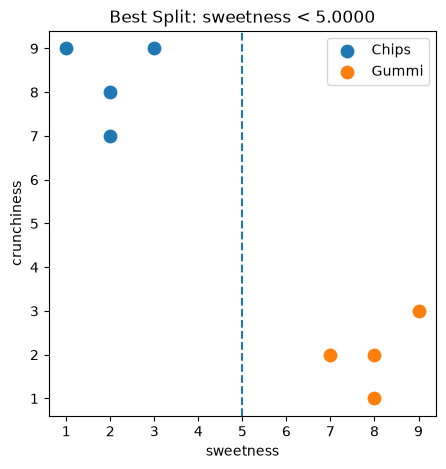

In [86]:
if best is not None and pd.api.types.is_numeric_dtype(X_snack[best["feature"]]) and X_snack.shape[1] == 2:
    feat = best["feature"]
    # Schwelle aus Detailtabelle ziehen
    ftype, df_full = details[feat]
    thr = df_full.iloc[0]["threshold"] if "threshold" in df_full.columns else None

    plt.figure(figsize=(5,5))
    # Punkte einfärben
    # (kein seaborn nötig)
    labels = y_snack.unique().tolist()
    for lbl in labels:
        m = (y_snack == lbl)
        plt.scatter(X_snack.loc[m, X_snack.columns[0]],
                    X_snack.loc[m, X_snack.columns[1]],
                    label=str(lbl), s=80)
    # Split-Linie zeichnen (vertikal oder horizontal)
    if feat == X_snack.columns[0] and thr is not None:
        plt.axvline(thr, linestyle="--")
    elif feat == X_snack.columns[1] and thr is not None:
        plt.axhline(thr, linestyle="--")
    plt.xlabel(X_snack.columns[0]); plt.ylabel(X_snack.columns[1])
    plt.title(f"Best Split: {best['rule']}")
    plt.legend()
    plt.show()